# Real Site Background Figure (Panels 2 and 3, high-resolution terrain)

This notebook keeps only the requested panels:

- (2) Local monitoring layout with high-resolution terrain background
- (3) Transect profile and sensor placement

Terrain source uses the USGS 3DEP dynamic ImageServer (Hillshade Gray) via `exportImage`.


In [30]:
from __future__ import annotations

import io
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import requests
from PIL import Image

plt.style.use("seaborn-v0_8-whitegrid")


def _pick_available_font(candidates: list[str]) -> str:
    for name in candidates:
        try:
            fm.findfont(name, fallback_to_default=False)
            return name
        except Exception:
            continue
    return "DejaVu Sans"


preferred_font = _pick_available_font(
    ["Arial", "Liberation Sans", "Nimbus Sans", "DejaVu Sans"]
)
plt.rcParams.update(
    {
        "font.family": preferred_font,
        "font.sans-serif": [preferred_font],
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "figure.dpi": 120,
    }
)

np.set_printoptions(precision=4, suppress=True)
print("Using font:", preferred_font)

Using font: DejaVu Sans


In [31]:
# Paths and base data
here = Path.cwd().resolve()
candidates = [here, *here.parents]
project_root = next(
    (
        p
        for p in candidates
        if (p / "ProcessedData").exists() and (p / "result").exists()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Cannot locate project root containing ProcessedData/ and result/."
    )

processed_dir = project_root / "ProcessedData"
locations_file = processed_dir / "Locations.csv"
projected_locations_file = (
    project_root
    / "result"
    / "8_real_data"
    / "2_timelapse_inversion_real_adtlert"
    / "real_sensor_locations_projected.csv"
)
output_dir = (
    project_root / "result" / "8_real_data" / "7_ad_delta_theta_sensor_calibrated"
)
terrain_cache_dir = project_root / "result" / "8_real_data" / "terrain_cache"
output_dir.mkdir(parents=True, exist_ok=True)
terrain_cache_dir.mkdir(parents=True, exist_ok=True)

save_figures = True
figure_dpi = 600

loc_df = pd.read_csv(locations_file)
proj_df = (
    pd.read_csv(projected_locations_file)
    if projected_locations_file.exists()
    else pd.DataFrame()
)

# Read one ERT file to recover topographic profile
ert_files = sorted(processed_dir.glob("*.txt"))
if not ert_files:
    raise FileNotFoundError("No ProcessedData/*.txt ERT files found.")


def read_electrodes(path: Path) -> np.ndarray:
    lines = [
        line.strip()
        for line in path.read_text(encoding="utf-8", errors="replace").splitlines()
        if line.strip()
    ]
    n_elec = int(lines[0].split()[0])
    arr = np.loadtxt(lines[2 : 2 + n_elec], dtype=float)
    if arr.ndim == 1:
        arr = arr[None, :]
    return arr


elec_xyz = read_electrodes(ert_files[0])
elec_x = np.asarray(elec_xyz[:, 0], dtype=float)
elec_z = np.asarray(elec_xyz[:, 2], dtype=float)
elec_z_rel = elec_z - float(np.max(elec_z))

print("project_root:", project_root)
print("locations rows:", len(loc_df), "projected rows:", len(proj_df))

project_root: /home/luffy/adtlertv1
locations rows: 10 projected rows: 6


In [32]:
# High-resolution terrain image from USGS 3DEP ImageServer
def download_usgs_3dep_hillshade(
    x_min: float,
    x_max: float,
    y_min: float,
    y_max: float,
    *,
    width_px: int = 3600,
    cache_dir: Path | None = None,
) -> np.ndarray:
    width_px = int(max(width_px, 600))
    aspect = max((y_max - y_min) / max((x_max - x_min), 1e-6), 0.2)
    height_px = int(max(400, round(width_px * aspect)))

    cache_file = None
    if cache_dir is not None:
        cache_file = (
            cache_dir
            / f"usgs_3dep_hillshade_{x_min:.1f}_{x_max:.1f}_{y_min:.1f}_{y_max:.1f}_{width_px}x{height_px}.png"
        )
        if cache_file.exists():
            return np.asarray(Image.open(cache_file).convert("L"), dtype=float)

    base = "https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ImageServer/exportImage"
    params = {
        "f": "image",
        "bbox": f"{x_min},{y_min},{x_max},{y_max}",
        "bboxSR": "32613",
        "imageSR": "32613",
        "size": f"{width_px},{height_px}",
        "format": "png32",
        "transparent": "true",
        "interpolation": "RSP_BilinearInterpolation",
        "renderingRule": '{"rasterFunction":"Hillshade Gray"}',
    }

    r = requests.get(base, params=params, timeout=90)
    r.raise_for_status()

    img = Image.open(io.BytesIO(r.content)).convert("L")
    if cache_file is not None:
        img.save(cache_file)
    return np.asarray(img, dtype=float)


# Query extent around the local instrumentation
mx = 35.0
my = 28.0
x_min = float(loc_df["Easting"].min() - mx)
x_max = float(loc_df["Easting"].max() + mx)
y_min = float(loc_df["Northing"].min() - my)
y_max = float(loc_df["Northing"].max() + my)

hillshade = download_usgs_3dep_hillshade(
    x_min, x_max, y_min, y_max, width_px=3600, cache_dir=terrain_cache_dir
)

# Contrast stretch for crisper local relief
p2, p98 = np.percentile(hillshade, [2, 98])
hillshade_stretched = np.clip((hillshade - p2) / max(p98 - p2, 1e-6), 0.0, 1.0)

print(
    "hillshade shape:",
    hillshade.shape,
    "raw min/max:",
    float(hillshade.min()),
    float(hillshade.max()),
)
print("display extent (UTM):", (x_min, x_max, y_min, y_max))

hillshade shape: (1452, 3600) raw min/max: 11.0 203.0
display extent (UTM): (328182.57, 328462.83, 4310375.84, 4310488.84)


saved: /home/luffy/adtlertv1/result/8_real_data/7_ad_delta_theta_sensor_calibrated/paper_site_background_23_terrain.png


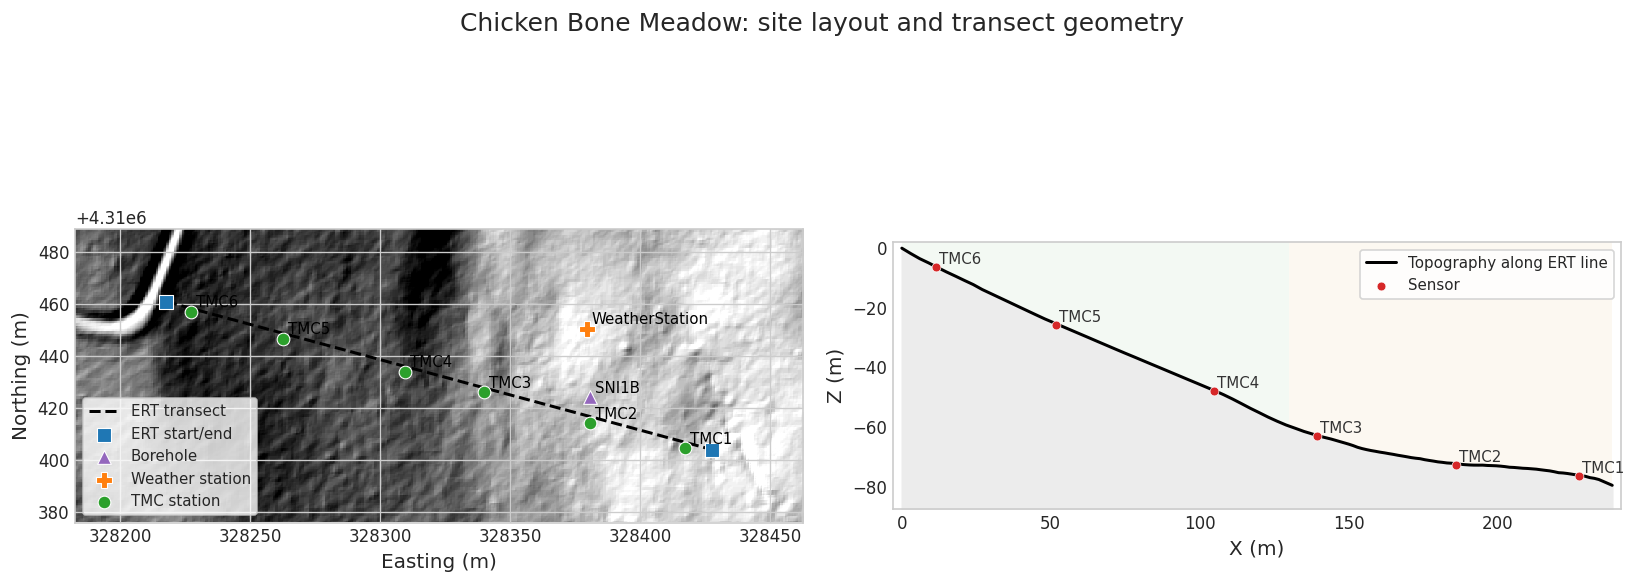

In [36]:
# Plot: keep only panel (2) and (3)
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(13.8, 5.6))

ax2.imshow(
    hillshade_stretched,
    extent=[x_min, x_max, y_min, y_max],
    origin="upper",
    cmap="gray",
    interpolation="nearest",
    alpha=1.0,
    zorder=0,
)

start_row = loc_df.loc[loc_df["ID"].eq("ERT-Start")].iloc[0]
end_row = loc_df.loc[loc_df["ID"].eq("ERT-End")].iloc[0]
ax2.plot(
    [start_row["Easting"], end_row["Easting"]],
    [start_row["Northing"], end_row["Northing"]],
    color="black",
    lw=1.8,
    ls="--",
    label="ERT transect",
    zorder=3,
)

type_map = {
    "ERT": dict(marker="s", s=68, color="#1f77b4", label="ERT start/end"),
    "Borehole": dict(marker="^", s=68, color="#9467bd", label="Borehole"),
    "Weather Station": dict(marker="P", s=84, color="#ff7f0e", label="Weather station"),
    "Soil Moisture and Temperature": dict(
        marker="o", s=58, color="#2ca02c", label="TMC station"
    ),
}
for typ, style in type_map.items():
    sub = loc_df.loc[loc_df["Type"].eq(typ)]
    if sub.empty:
        continue
    ax2.scatter(
        sub["Easting"],
        sub["Northing"],
        marker=style["marker"],
        s=style["s"],
        color=style["color"],
        edgecolors="white",
        linewidths=0.65,
        label=style["label"],
        zorder=4,
    )

for _, row in loc_df.iterrows():
    rid = str(row["ID"])
    if rid.startswith("TMC") or rid in ("SNI1B", "WeatherStation"):
        ax2.text(
            float(row["Easting"]) + 1.8,
            float(row["Northing"]) + 1.8,
            rid,
            fontsize=9,
            color="black",
            zorder=5,
        )
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_aspect("equal", adjustable="box")
ax2.set_xlabel("Easting (m)")
ax2.set_ylabel("Northing (m)")
handles2, labels2 = ax2.get_legend_handles_labels()
uniq2 = dict(zip(labels2, handles2))
ax2.legend(uniq2.values(), uniq2.keys(), loc="lower left", frameon=True)

# -------------------------------------------
# Panel (3): transect profile + sensor depths
# -------------------------------------------
ax3.plot(
    elec_x,
    elec_z_rel,
    color="black",
    lw=1.8,
    label="Topography along ERT line",
    zorder=3,
)

sensor_plot_depth = (
    0.3  # Plot one representative sensor point 0.3 m below local topography.
)
tmc_proj = (
    proj_df.loc[proj_df["ID"].astype(str).str.startswith("TMC")].sort_values(
        "profile_x_m"
    )
    if not proj_df.empty
    else proj_df
)

if not tmc_proj.empty:
    sensor_x = tmc_proj["profile_x_m"].to_numpy(dtype=float)
    sensor_line_z = np.interp(sensor_x, elec_x, elec_z_rel)
    sensor_z = sensor_line_z - sensor_plot_depth
    sensor_floor = float(np.min(sensor_z))
else:
    sensor_floor = float(np.min(elec_z_rel))

# Fill to a bottom that is deep enough for terrain and sensor markers.
fill_bottom = min(float(np.min(elec_z_rel)) - 8.0, sensor_floor - 2.0)
ax3.fill_between(elec_x, elec_z_rel, fill_bottom, color="#ececec", alpha=0.95, zorder=1)

if not tmc_proj.empty:
    ax3.scatter(
        sensor_x,
        sensor_z,
        marker="o",
        s=28,
        color="#d62728",
        edgecolors="white",
        linewidths=0.4,
        zorder=5,
        label="Sensor",
    )
    for x0, z0, sid in zip(sensor_x, sensor_z, tmc_proj["ID"].astype(str), strict=True):
        ax3.text(float(x0) + 1.0, float(z0) + 1.0, sid, fontsize=9, color="#333333")

x_split = 130.0
ax3.axvspan(float(np.min(elec_x)), x_split, color="#cfe8cf", alpha=0.24, lw=0, zorder=0)
ax3.axvspan(x_split, float(np.max(elec_x)), color="#f5e2c8", alpha=0.24, lw=0, zorder=0)

handles3, labels3 = ax3.get_legend_handles_labels()
uniq3 = dict(zip(labels3, handles3))
ax3.legend(uniq3.values(), uniq3.keys(), loc="upper right", frameon=True)

ax3.set_xlim(float(np.min(elec_x)) - 3.0, float(np.max(elec_x)) + 3.0)
ax3.set_ylim(fill_bottom, 2.0)
ax3.set_aspect("equal", adjustable="box")
ax3.set_xlabel("X (m)")
ax3.set_ylabel("Z (m)")
ax3.grid(False)

fig.suptitle(
    "Chicken Bone Meadow: site layout and transect geometry", fontsize=15, y=0.99
)
fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])

out_png = output_dir / "paper_site_background_23_terrain.png"
if save_figures:
    fig.savefig(out_png, dpi=figure_dpi, bbox_inches="tight")
    print("saved:", out_png)

plt.show()